In [1]:
# Celda 1 - Importar librerías
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

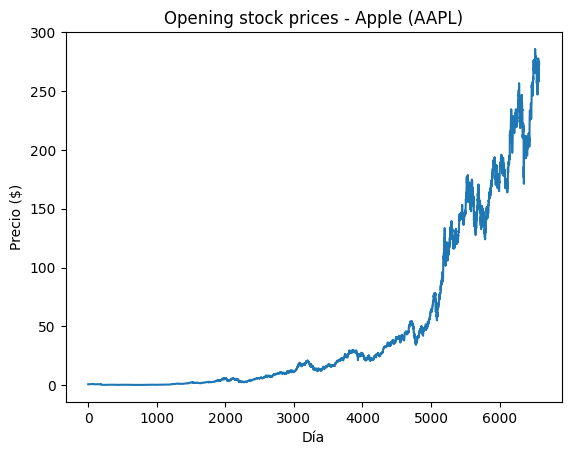

In [16]:
# Celda 2 - Obtener datos históricos de Microsoft
def get_prices(share_symbol, start_date, end_date, cache_filename):
    try:
        stock_prices = np.load(cache_filename)
    except IOError:
        stock = yf.download(share_symbol, start=start_date, end=end_date)
        stock_prices = stock['Open'].values
        np.save(cache_filename, stock_prices)
    return stock_prices

# Celda 3 - Graficar precios
def plot_prices(prices):
    plt.title('Opening stock prices - Apple (AAPL)')
    plt.xlabel('Día')
    plt.ylabel('Precio ($)')
    plt.plot(prices)
    plt.savefig('prices.png')
    plt.show()

# Obtener y graficar datos de 2000 a 2025
prices = get_prices('AAPL', '2000-01-01', '2026-03-01', 'historical_stock_prices_aapl.npy')
prices = prices.flatten()
plot_prices(prices)

In [17]:
# Celda 3 - Clases de política de decisión
import random

class DecisionPolicy:
    def select_action(self, current_state, step):
        pass
    def update_q(self, state, action, reward, next_state):
        pass

class RandomDecisionPolicy(DecisionPolicy):
    def __init__(self, actions):
        self.actions = actions
    def select_action(self, current_state, step):
        action = self.actions[random.randint(0, len(self.actions) - 1)]
        return action
    def update_q(self, state, action, reward, next_state):
        pass

In [18]:
# Celda 4 - Función de simulación (corregida)
def run_simulation(policy, initial_budget, initial_num_stocks, prices, hist, debug=False):
    budget = initial_budget
    num_stocks = initial_num_stocks
    share_value = 0
    transitions = list()

    for i in range(len(prices) - hist - 1):
        if i % 100 == 0:
            print('Progreso: {:.2f}%'.format(float(100 * i) / (len(prices) - hist - 1)))

        current_state = np.array(list(prices[i:i+hist].flatten()) + [budget, num_stocks]).reshape(1, -1)
        current_portfolio = budget + num_stocks * share_value
        action = policy.select_action(current_state, i)
        share_value = float(prices[i + hist + 1])

        if action == 'Buy' and budget >= share_value:
            budget -= share_value
            num_stocks += 1
        elif action == 'Sell' and num_stocks > 0:
            budget += share_value
            num_stocks -= 1
        else:
            action = 'Hold'

        new_portfolio = budget + num_stocks * share_value
        reward = new_portfolio - current_portfolio
        next_state = np.array(list(prices[i+1:i+hist+1].flatten()) + [budget, num_stocks]).reshape(1, -1)
        transitions.append((current_state, action, reward, next_state))
        policy.update_q(current_state, action, reward, next_state)

    portfolio = budget + num_stocks * share_value
    if debug:
        print('${}\t{} acciones'.format(budget, num_stocks))
    return portfolio

In [19]:
# Celda 5 - Correr simulaciones múltiples
def run_simulations(policy, budget, num_stocks, prices, hist):
    num_tries = 100
    final_portfolios = list()
    for i in range(num_tries):
        final_portfolio = run_simulation(policy, budget, num_stocks, prices, hist)
        final_portfolios.append(final_portfolio)
    avg, std = np.mean(final_portfolios), np.std(final_portfolios)
    return avg, std

# Evaluar política aleatoria
actions = ['Buy', 'Sell', 'Hold']
hist = 200
policy = RandomDecisionPolicy(actions)
budget = 1000.0
num_stocks = 0

avg, std = run_simulations(policy, budget, num_stocks, prices, hist)
print('Portafolio promedio: ${:.2f}'.format(avg))
print('Desviación estándar: ${:.2f}'.format(std))

Progreso: 0.00%
Progreso: 1.57%
Progreso: 3.14%
Progreso: 4.70%
Progreso: 6.27%
Progreso: 7.84%
Progreso: 9.41%
Progreso: 10.98%
Progreso: 12.55%
Progreso: 14.11%
Progreso: 15.68%
Progreso: 17.25%
Progreso: 18.82%
Progreso: 20.39%
Progreso: 21.95%
Progreso: 23.52%
Progreso: 25.09%
Progreso: 26.66%
Progreso: 28.23%
Progreso: 29.79%
Progreso: 31.36%
Progreso: 32.93%
Progreso: 34.50%
Progreso: 36.07%
Progreso: 37.64%
Progreso: 39.20%
Progreso: 40.77%
Progreso: 42.34%
Progreso: 43.91%
Progreso: 45.48%
Progreso: 47.04%
Progreso: 48.61%
Progreso: 50.18%
Progreso: 51.75%
Progreso: 53.32%
Progreso: 54.88%
Progreso: 56.45%
Progreso: 58.02%
Progreso: 59.59%
Progreso: 61.16%
Progreso: 62.73%
Progreso: 64.29%
Progreso: 65.86%
Progreso: 67.43%
Progreso: 69.00%
Progreso: 70.57%
Progreso: 72.13%
Progreso: 73.70%
Progreso: 75.27%
Progreso: 76.84%
Progreso: 78.41%
Progreso: 79.97%
Progreso: 81.54%
Progreso: 83.11%
Progreso: 84.68%
Progreso: 86.25%
Progreso: 87.82%
Progreso: 89.38%
Progreso: 90.95%
Prog

In [20]:
# Celda 6 - Política Q-Learning con red neuronal
import tensorflow as tf

class QLearningDecisionPolicy(DecisionPolicy):
    def __init__(self, actions, input_dim):
        self.epsilon = 0.9
        self.gamma = 0.001
        self.actions = actions
        output_dim = len(actions)
        h1_dim = 200

        self.model = tf.keras.Sequential([
            tf.keras.layers.Dense(h1_dim, activation='relu', input_shape=(input_dim,)),
            tf.keras.layers.Dense(output_dim, activation='relu')
        ])
        self.model.compile(optimizer=tf.keras.optimizers.SGD(0.01), loss='mse')

    def select_action(self, current_state, step):
        threshold = min(self.epsilon, step / 1000.)
        if random.random() < threshold:
            action_q_vals = self.model.predict(current_state, verbose=0)
            action_idx = np.argmax(action_q_vals)
            action = self.actions[action_idx]
        else:
            action = self.actions[random.randint(0, len(self.actions) - 1)]
        return action

    def update_q(self, state, action, reward, next_state):
        action_q_vals = self.model.predict(state, verbose=0)
        next_action_q_vals = self.model.predict(next_state, verbose=0)
        next_action_idx = np.argmax(next_action_q_vals)
        action_idx = self.actions.index(action)
        action_q_vals[0, action_idx] = reward + self.gamma * next_action_q_vals[0, next_action_idx]
        self.model.fit(state, action_q_vals, verbose=0)

In [21]:
# Celda 7 - Evaluar política Q-Learning
input_dim = hist + 2  # 200 precios + presupuesto + acciones = 202
policy_ql = QLearningDecisionPolicy(actions, input_dim)

print("Entrenando agente inteligente (tarda más que el aleatorio)...")
avg_ql, std_ql = run_simulations(policy_ql, budget, num_stocks, prices, hist)

print('\n--- COMPARACIÓN DE RESULTADOS ---')
print('Política Aleatoria:')
print('  Portafolio promedio: ${:.2f}'.format(avg))
print('  Desviación estándar: ${:.2f}'.format(std))
print('\nPolítica Q-Learning:')
print('  Portafolio promedio: ${:.2f}'.format(avg_ql))
print('  Desviación estándar: ${:.2f}'.format(std_ql))

c:\Users\Leticia\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando agente inteligente (tarda más que el aleatorio)...
Progreso: 0.00%
Progreso: 1.57%
Progreso: 3.14%
Progreso: 4.70%
Progreso: 6.27%
Progreso: 7.84%
Progreso: 9.41%
Progreso: 10.98%
Progreso: 12.55%
Progreso: 14.11%
Progreso: 15.68%
Progreso: 17.25%
Progreso: 18.82%
Progreso: 20.39%
Progreso: 21.95%
Progreso: 23.52%
Progreso: 25.09%
Progreso: 26.66%
Progreso: 28.23%
Progreso: 29.79%
Progreso: 31.36%
Progreso: 32.93%
Progreso: 34.50%
Progreso: 36.07%
Progreso: 37.64%
Progreso: 39.20%
Progreso: 40.77%
Progreso: 42.34%
Progreso: 43.91%
Progreso: 45.48%
Progreso: 47.04%
Progreso: 48.61%
Progreso: 50.18%
Progreso: 51.75%
Progreso: 53.32%
Progreso: 54.88%
Progreso: 56.45%
Progreso: 58.02%
Progreso: 59.59%
Progreso: 61.16%
Progreso: 62.73%
Progreso: 64.29%
Progreso: 65.86%
Progreso: 67.43%
Progreso: 69.00%
Progreso: 70.57%
Progreso: 72.13%
Progreso: 73.70%
Progreso: 75.27%


KeyboardInterrupt: 